<a href="https://colab.research.google.com/github/gopaps/MachineLearning/blob/main/TUGAS%20PERBAIKAN/Chapter_1_Tugas_Perbaikan_Anda_Figo_Haq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classifying Iris
In this section, we will go through a simple machine learning application and create
our first model. In the process, we will introduce some core concepts and terms.

We started with a brief introduction
to machine learning and its applications, then discussed the distinction between
supervised and unsupervised learning and gave an overview of the tools we’ll be
using in this book.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import torch

In [11]:
pip install torch torchvision

In [12]:
# Periksa apakah GPU tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU tersedia. Menggunakan:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU tidak tersedia. Menggunakan CPU.")


GPU tersedia. Menggunakan: Tesla T4


In [13]:
# Memuat dataset Iris
data = load_iris()
X = data.data
y = data.target

# Konversi data menjadi tensor torch untuk potensi penggunaan GPU
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y, dtype=torch.long, device=device)

In [14]:
# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Klasifikasi K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

Akurasi Model: 95.56%


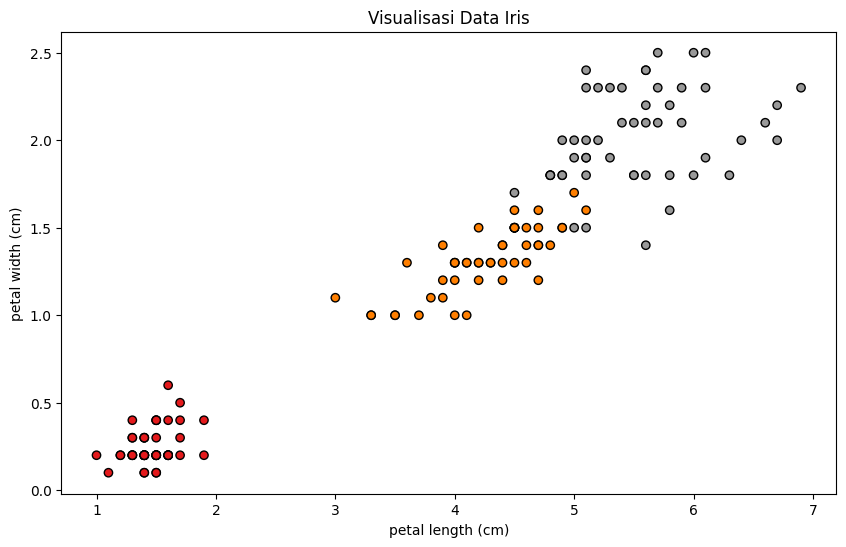

In [15]:
# Membuat prediksi
y_pred = knn.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")

# Visualisasi data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 2], X[:, 3], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel(data.feature_names[2])
plt.ylabel(data.feature_names[3])
plt.title("Visualisasi Data Iris")
plt.show()
